# Laboratorio Práctico 2 · Pipeline ETL reproducible

**Curso:** Análisis de Datos  
**Programa:** Magíster en Data Science  
**Universidad del Desarrollo**

**Nombre estudiante:**  
**Fecha:**  

---

## Contexto del problema

En el Laboratorio Práctico 1 se realizó un diagnóstico inicial de calidad sobre un conjunto de datos de clientes de una empresa de retail.

En este laboratorio se utilizarán esos mismos datos para construir un **pipeline reproducible de extracción, transformación y preparación de datos (ETL)**.

El objetivo no es simplemente corregir valores, sino desarrollar un proceso documentado que permita transformar los datos originales en una versión preparada para análisis posteriores.

Una decisión importante del proceso será distinguir entre:

- errores o problemas de calidad que requieren tratamiento;
- valores faltantes que requieren una estrategia explícita;
- inconsistencias que deben investigarse antes de modificarse;
- valores que pueden parecer extraños, pero que podrían ser válidos.

El resultado final debe poder reproducirse ejecutando nuevamente el notebook desde el comienzo.


## Objetivos del laboratorio

Al finalizar esta actividad, se espera que usted sea capaz de:

1. Implementar un proceso reproducible de carga y transformación de datos.
2. Estandarizar tipos y categorías de variables.
3. Detectar y tratar valores faltantes utilizando criterios justificados.
4. Identificar inconsistencias entre variables y documentar las decisiones adoptadas.
5. Crear variables derivadas cuando aporten valor al análisis posterior.
6. Validar la calidad del dataset antes y después del proceso ETL.
7. Documentar las transformaciones realizadas de manera que otra persona pueda comprender y reproducir el proceso.


## 1. Importación de librerías

Importe las librerías necesarias para desarrollar el pipeline.

Se recomienda utilizar:

- pandas
- numpy
- matplotlib
- seaborn

Puede utilizar otras librerías si son necesarias, pero debe justificar su utilización.


In [1]:
# Importación de librerías

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Extract · Carga de los datos originales

Cargue el archivo `clientes_retail.csv`.

El archivo original debe conservarse sin modificaciones. Todas las transformaciones posteriores deben realizarse sobre una copia del dataset.

Incluya:

- carga reproducible del archivo;
- verificación de cantidad de filas y columnas;
- revisión de los nombres de variables;
- una primera inspección de los datos.

### Importante

No modifique directamente el archivo CSV original.


In [2]:
# Carga de los datos originales

df = pd.read_csv("clientes_retail.csv")

## 3. Diagnóstico inicial del dataset

Antes de realizar transformaciones, construya una línea base que permita comparar el estado de los datos antes y después del proceso ETL.

Evalúe al menos:

- cantidad de registros;
- cantidad de variables;
- tipos de datos;
- valores faltantes;
- registros duplicados;
- categorías relevantes;
- rangos básicos de variables numéricas.

No es necesario repetir todo el análisis exploratorio realizado en el Laboratorio 1. El foco debe estar en identificar los aspectos que serán relevantes para las transformaciones posteriores.


In [3]:
# Diagnóstico inicial

rows, cols = df.shape
colNames = list(df.columns)
print("Cantidad de registros:", rows)
print("Cantidad de variables:", cols)
dataTypes = {
    "object": "categóricas",
    "int64": "numéricas",
    "float64": "numéricas"
}

colTypes = { c: "temporales" if c == "registration_date" else dataTypes[str(df[c].dtype)] for c in colNames }
lstTypes = { t: [ c for c in colNames if colTypes[c] == t ] for t in colTypes.values() }

for t, lc in lstTypes.items():
    print(f"Variables {t}:", ", ".join(lc))
nullValues = { c: df[c].isnull().sum() for c in colNames if df[c].isnull().sum() > 0 }
duplRec = df.duplicated().sum()
print("Valores faltantes:\n\t-", "\n\t- ".join([ f"{c}: {n}" for c, n in nullValues.items() ]))
print("Registros duplicados:", duplRec)
print("Inconsistencias categóricas:")
for c in [ c0 for c0 in lstTypes["categóricas"] if c0 not in ["customer_id"] ]:
    print(f"\tValores de {c}:\n\t\t-", "\n\t\t- ".join([ f"{str(v)}: {str((df[c] == v).sum())}" for v in list(df[c].unique()) ]))
numQuants = { c: [ df[c].quantile(n / 4) for n in [1, 3] ] for c in lstTypes["numéricas"] }
numIR = { c: [ numQuants[c][n] - numQuants[c][1 - n] for n in range(2)] for c in lstTypes["numéricas"] }
irFactor = 1.5
numRange = { c: [ numQuants[c][n] + irFactor * numIR[c][n] for n in range(2) ] for c in lstTypes["numéricas"] }
outliers = { c: [ sorted(list({ i for i in df[c] if [-1, 1][n] * i > [-1, 1][n] * numRange[c][n] })) for n in range(2)] for c in lstTypes["numéricas"] }
print("Valores extremos:")
for c, o in outliers.items():
    if sum([ len(s) for s in o ]) > 0:
        print(f"\t- {c}:\n\t\t-", "\n\t\t- ".join([ f"Outliers " + ["inferiores", "superiores"][n] + ":\n\t\t\t- " + "\n\t\t\t- ".join([ str(l) for l in o[n] ]) for n in range(2) if len(o[n]) > 0 ]))

Cantidad de registros: 1020
Cantidad de variables: 15
Variables categóricas: customer_id, gender, education, marital_status, region
Variables numéricas: age, income_clp, total_purchases, total_spent_clp, online_purchases, store_purchases, complaints, satisfaction_score, last_purchase_days
Variables temporales: registration_date
Valores faltantes:
	- education: 51
	- income_clp: 104
	- satisfaction_score: 30
Registros duplicados: 20
Inconsistencias categóricas:
	Valores de gender:
		- Femenino: 495
		- Masculino: 465
		- femenino: 10
		- Hombre: 11
		- Otro: 19
		- FEMENINO: 10
		- M: 10
	Valores de education:
		- Media: 234
		- Técnica: 346
		- Universitaria: 332
		- Postgrado: 57
		- nan: 0
	Valores de marital_status:
		- Soltero: 234
		- Casado: 247
		- Divorciado: 257
		- Viudo: 282
	Valores de region:
		- Biobío: 235
		- Araucanía: 245
		- Metropolitana: 257
		- Valparaíso: 251
		- Region Metropolitana: 10
		- Santiago: 12
		- RM: 10
Valores extremos:
	- age:
		- Outliers inferiore

## 4. Plan de transformación

Antes de modificar los datos, defina un plan de transformación.

Construya una tabla o estructura equivalente que documente, para cada problema identificado:

- variable afectada;
- problema detectado;
- tratamiento propuesto;
- justificación;
- impacto esperado.

No se espera que todos los valores extraños sean modificados automáticamente. Una transformación debe estar respaldada por un criterio analítico o de negocio.

### Ejemplo

| Variable | Problema | Tratamiento | Justificación |
|---|---|---|---|
| `registration_date` | Tipo incorrecto | Convertir a fecha | Permitir análisis temporal |
| `gender` | Categorías inconsistentes | Estandarizar | Evitar categorías duplicadas por formato |

Complete la tabla con los problemas que considere relevantes en el dataset.


## 5. Transformación de tipos y formatos

Revise y transforme los tipos de datos que sean necesarios para trabajar correctamente con el dataset.

Considere especialmente:

- fechas;
- variables numéricas;
- variables categóricas;
- identificadores.

Después de realizar las transformaciones, verifique que los tipos obtenidos sean los esperados.

Documente cualquier decisión que no sea evidente.


In [4]:
# Transformación de tipos y formatos

pd.DataFrame({
    "Variable": [
        "customer_id",
        "age",
        "gender",
        "education",
        "income_clp",
        "region",
        "registration_date",
        "total_spent_clp",
        "complaints",
        "satisfaction_score"
    ],
    "Problema": [
        "Datos duplicados",
        "Datos fuera de rango",
        "Categorías inconsistentes",
        "Datos faltantes",
        "Datos faltantes o fuera de rango",
        "Categorías inconsistentes",
        "Tipo incorrecto",
        "Datos fuera de rango",
        "Datos fuera de rango",
        "Datos faltantes o fuera de rango"
    ],
    "Tratamiento": [
        "Eliminar registros",
        "Eliminar o marcar registros",
        "Estandarizar",
        "Conservar",
        "Eliminar o marcar registros",
        "Estandarizar",
        "Convertir a fecha",
        "Eliminar o marcar registros",
        "Eliminar o marcar registros",
        "Eliminar registros"
    ],
    "Justificación": [
        "Evitar registros duplicados",
        "Protección al menor",
        "Evitar categorías duplicadas por formato",
        "Que los valores nulos sean una categoría",
        "Evitar valores negativos o nulos",
        "Evitar categorías duplicadas por formato",
        "Permitir análisis temporal",
        "Evitar valores negativos",
        "Evitar valores negativos",
        "Evitar valores fuera de rango"
    ]
})

,Variable,Problema,Tratamiento,Justificación
0,customer_id,Datos duplicados,Eliminar registros,Evitar registros duplicados
1,age,Datos fuera de rango,Eliminar o marcar registros,Protección al menor
2,gender,Categorías inconsistentes,Estandarizar,Evitar categorías duplicadas por formato
3,education,Datos faltantes,Conservar,Que los valores nulos sean una categoría
4,income_clp,Datos faltantes o fuera de rango,Eliminar o marcar registros,Evitar valores negativos o nulos
5,region,Categorías inconsistentes,Estandarizar,Evitar categorías duplicadas por formato
6,registration_date,Tipo incorrecto,Convertir a fecha,Permitir análisis temporal
7,total_spent_clp,Datos fuera de rango,Eliminar o marcar registros,Evitar valores negativos
8,complaints,Datos fuera de rango,Eliminar o marcar registros,Evitar valores negativos
9,satisfaction_score,Datos faltantes o fuera de rango,Eliminar registros,Evitar valores fuera de rango


## 6. Estandarización de variables categóricas

Identifique variables categóricas que presenten diferencias de formato o escritura.

Por ejemplo, una misma categoría podría aparecer utilizando diferencias de mayúsculas o minúsculas.

Realice una estandarización reproducible cuando corresponda.

Después de transformar los datos:

- revise las categorías resultantes;
- compruebe que no se hayan creado categorías artificiales;
- documente las reglas utilizadas.


In [5]:
# Estandarización de variables categóricas

cleaningValues = {
    "gender": {
        "femenino" : "Femenino",
        "Hombre": "Masculino",
        "Otro": "Otro",
        "FEMENINO": "Femenino",
        "M": "Masculino"
    },
    "region": {
        "Region Metropolitana": "Metropolitana",
        "Santiago": "Metropolitana",
        "RM": "Metropolitana"
    }
}

df1 = df.assign(
    registration_date = pd.to_datetime(df["registration_date"], dayfirst = True).dt.date
)

for c, vd in cleaningValues.items():
    df1[c] = df1[c].map(vd).fillna(df1[c])

## 7. Valores faltantes

Identifique las variables que presentan valores faltantes y determine una estrategia de tratamiento para cada caso relevante.

Las estrategias pueden incluir, dependiendo del contexto:

- imputación;
- conservación del valor faltante;
- eliminación de registros;
- creación de indicadores de ausencia;
- utilización de reglas específicas de negocio.

No utilice una única estrategia para todas las variables sin justificarla.

Para cada decisión explique:

- por qué eligió esa estrategia;
- qué supuestos está realizando;
- qué posibles efectos puede tener sobre análisis posteriores.


In [6]:
# Tratamiento de valores faltantes

df2 = df1[
    ~df1["income_clp"].isnull()
].assign(
    education = df1["education"].fillna("NA")
)
df2.describe()

,age,income_clp,total_purchases,total_spent_clp,online_purchases,store_purchases,complaints,satisfaction_score,last_purchase_days
count,916.000000,9.160000e+02,916.000000,9.160000e+02,916.000000,916.000000,916.000000,891.000000,916.000000
mean,42.097162,1.344718e+06,15.167031,1.070186e+06,7.030568,8.027293,1.111354,3.662177,185.932314
std,12.850989,1.009656e+06,3.716959,2.381165e+06,2.672905,2.842364,1.915893,1.081673,103.495919
min,18.000000,-5.000000e+05,3.000000,-3.000000e+04,1.000000,1.000000,-1.000000,0.000000,2.000000
25%,34.000000,8.591062e+05,12.750000,5.241288e+05,5.000000,6.000000,0.000000,3.000000,100.000000
50%,42.000000,1.200099e+06,15.000000,8.075970e+05,7.000000,8.000000,1.000000,4.000000,194.000000
75%,49.000000,1.618652e+06,18.000000,1.198178e+06,9.000000,10.000000,2.000000,4.000000,276.250000
max,150.000000,2.500000e+07,27.000000,5.000000e+07,18.000000,19.000000,50.000000,10.000000,364.000000


## 8. Reglas de consistencia y validación

Identifique relaciones entre variables que permitan detectar posibles inconsistencias.

Por ejemplo, considere la relación entre:

- `total_purchases`;
- `online_purchases`;
- `store_purchases`.

Evalúe si existe una regla de consistencia que pueda aplicarse y determine qué hacer cuando dicha regla no se cumple.

### Importante

No asuma automáticamente que una diferencia entre variables representa un error. Considere las posibles definiciones de negocio y documente sus supuestos.

Proponga al menos una regla de validación adicional que considere relevante para este dataset.


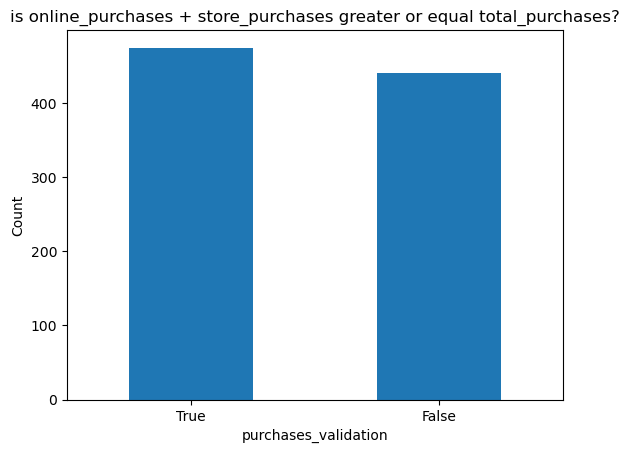

In [7]:
# Reglas de consistencia y validación

(df2["online_purchases"] + df2["store_purchases"] >= df2["total_purchases"]).value_counts().plot(kind = "bar")
plt.title("is online_purchases + store_purchases greater or equal total_purchases?")
plt.xlabel("purchases_validation")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()
df3 = df2.assign(
    purchases_validation = (df2["online_purchases"] + df2["store_purchases"] >= df2["total_purchases"])
)

## 9. Valores extremos y decisiones de transformación

Revise las variables numéricas relevantes e identifique posibles valores extremos.

No es obligatorio eliminar outliers.

Para los casos identificados, determine si corresponde:

- mantenerlos;
- transformarlos;
- marcarlos mediante una variable indicadora;
- excluirlos bajo una regla explícita.

Justifique la decisión adoptada.

El objetivo es demostrar criterio analítico, no eliminar automáticamente todos los valores extremos.


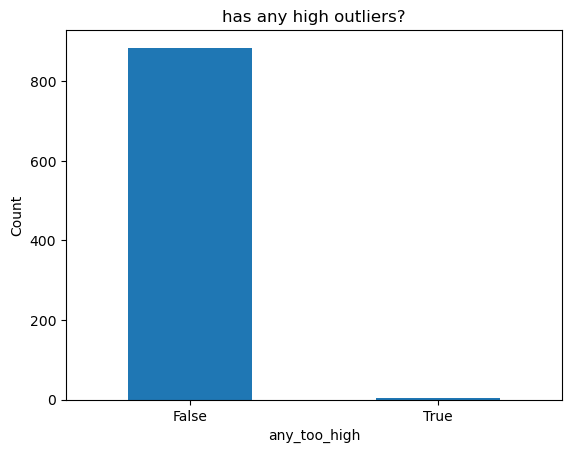

,age,income_clp,total_purchases,total_spent_clp,online_purchases,store_purchases,complaints,satisfaction_score,last_purchase_days
count,889.000000,8.890000e+02,889.000000,8.890000e+02,889.000000,889.000000,889.000000,865.000000,889.000000
mean,41.978628,1.356626e+06,15.160855,1.023558e+06,7.042745,8.022497,1.116985,3.645087,186.219348
std,12.391084,1.018125e+06,3.720530,1.770145e+06,2.666183,2.831919,1.938768,1.028552,103.181148
min,18.000000,3.211230e+05,3.000000,1.445270e+05,1.000000,1.000000,0.000000,1.000000,2.000000
25%,34.000000,8.646010e+05,13.000000,5.315720e+05,5.000000,6.000000,0.000000,3.000000,100.000000
50%,42.000000,1.206768e+06,15.000000,8.089460e+05,7.000000,8.000000,1.000000,4.000000,195.000000
75%,49.000000,1.631097e+06,18.000000,1.206590e+06,9.000000,10.000000,2.000000,4.000000,276.000000
max,150.000000,2.500000e+07,27.000000,5.000000e+07,18.000000,19.000000,50.000000,5.000000,364.000000


In [8]:
# Evaluación y tratamiento de valores extremos

df4 = df3[
    ~df3.duplicated() &
    (df3["age"] >= 18) &
    (df3["income_clp"] > 0) &
    (df3["total_spent_clp"] >= 0) &
    (df3["complaints"] >= 0) &
    (((df3["satisfaction_score"] >= 1) &
    (df3["satisfaction_score"] <= 5)) | df3["satisfaction_score"].isnull())
].assign(
    too_high_age = lambda x: x["age"] > 100,
    too_high_income_clp = lambda x: x["income_clp"] > 1e7,
    too_high_total_spent_clp = lambda x: x["total_spent_clp"] > 1e7,
    too_high_complaints = lambda x: x["complaints"] > 10,
    any_too_high = lambda x: x["too_high_age"] | x["too_high_income_clp"] | x["too_high_total_spent_clp"] | x["too_high_complaints"]
)
df4["any_too_high"].value_counts().plot(kind = "bar")
plt.title("has any high outliers?")
plt.xlabel("any_too_high")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()
df4.describe()

## 10. Transformación e ingeniería de variables

Construya al menos **dos variables derivadas** que puedan aportar valor para análisis posteriores.

Las variables deben construirse utilizando información disponible en el dataset y deben tener una interpretación clara.

Para cada variable creada indique:

- nombre;
- fórmula o regla utilizada;
- interpretación;
- utilidad potencial para análisis posteriores.

Ejemplos posibles incluyen indicadores relacionados con comportamiento de compra, antigüedad del cliente o intensidad de uso de canales. No es necesario utilizar estos ejemplos exactamente.


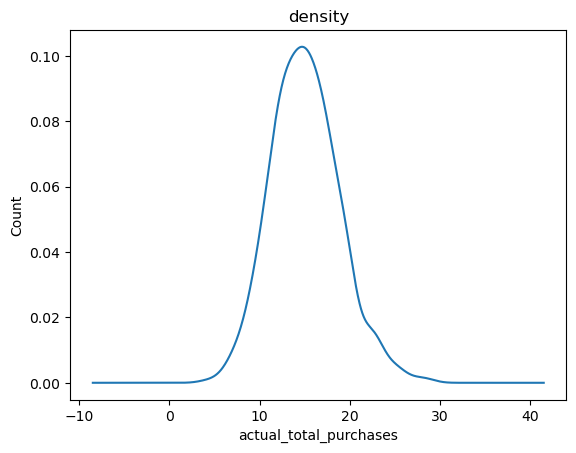

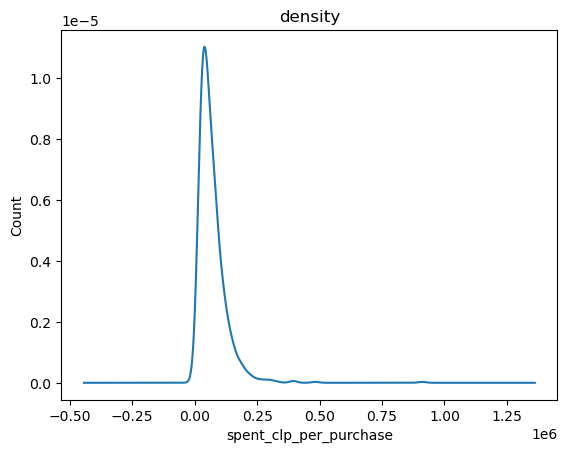

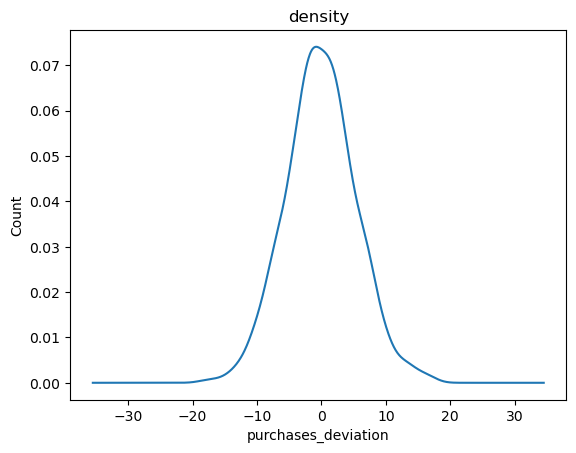

In [9]:
# Ingeniería de variables

df5 = df4.assign(
    actual_total_purchases = lambda x: x["online_purchases"] + x["store_purchases"],
    spent_clp_per_purchase = lambda x: x["total_spent_clp"] / x["actual_total_purchases"],
    purchases_deviation = lambda x: x["actual_total_purchases"] - x["total_purchases"]
)
df5["actual_total_purchases"][~df5["any_too_high"]].plot(kind = "density")
plt.title("density")
plt.xlabel("actual_total_purchases")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()
df5["spent_clp_per_purchase"][~df5["any_too_high"]].plot(kind = "density")
plt.title("density")
plt.xlabel("spent_clp_per_purchase")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()
df5["purchases_deviation"][~df5["any_too_high"]].plot(kind = "density")
plt.title("density")
plt.xlabel("purchases_deviation")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

### actual_total_purchases

- Nombre: `actual_total_purchases`
- Fórmula: $\text{actual_total_purchases} = \text{online_purchases} + \text{store_purchases}$
- Interpretación: Total de compras basado en la cantidad de compras online y en tienda
- Utilidad Potencial: Crear otras variables a partir de la cantidad calculada de compras 

### spent_clp_per_purchase

- Nombre: `spent_clp_per_purchase`
- Fórmula: $\text{spent_clp_per_purchase} = \frac{\text{total_spent_clp}}{\text{actual_total_purchases}}$
- Interpretación: Cantidad de dinero gastada por compra
- Utilidad Potencial: Explorar la correlación entre el estado civil o nivel educativo con la cantidad de dinero gastado por compra

### purchases_deviation

- Nombre: `purchases_deviation`
- Fórmula: $\text{purchases_deviation} = \text{actual_total_purchases} - \text{total_purchases}$
- Interpretación: Si $\text{purchases_deviation} > 0$, representa la cantidad de compras que no están registradas como parte del total, también podría representar la cantidad de compras que están registradas como online y en tienda en caso de que eso sea posible ($\left| A \cap B \right| = \left| A \right| + \left| B \right| - \left| A \cup B \right|$), si $\text{purchases_deviation} < 0$, su valor absoluto representa la cantidad de compras que no están registradas ni como online ni como en tienda, también podría representar la cantidad de compras registradas con una categoría que no aparece en la tabla en caso de que eso sea posible
- Utilidad potencial: Calcular la desviación entre la cantidad de compras calculadas y la cantidad de compras registradas

## 11. Validación del dataset transformado

Una vez finalizadas las transformaciones, realice un nuevo diagnóstico de calidad.

Compare el estado del dataset antes y después del proceso ETL.

Verifique al menos:

- cantidad de registros;
- cantidad de variables;
- tipos de datos;
- valores faltantes;
- duplicados;
- categorías estandarizadas;
- reglas de consistencia;
- variables derivadas.

La validación debe demostrar mediante evidencia que el pipeline produjo el resultado esperado.


In [10]:
# Validación final del dataset

rows1, cols1 = df5.shape
colNames1 = list(df5.columns)
print("Cantidad de registros:", rows1)
print("Cantidad de variables:", cols1)
dataTypes1 = {
    "object": "categóricas",
    "int64": "numéricas",
    "float64": "numéricas",
    "bool": "booleanas"
}
colTypes1 = { c: "temporales" if c == "registration_date" else dataTypes1[str(df5[c].dtype)] for c in colNames1 }
lstTypes1 = { t: [ c for c in colNames1 if colTypes1[c] == t ] for t in colTypes1.values() }
for t, lc in lstTypes1.items():
    print(f"Variables {t}:", ", ".join(lc))
nullValues1 = { c: df5[c].isnull().sum() for c in colNames1 if df5[c].isnull().sum() > 0 }
duplRec1 = df5.duplicated().sum()
print("Valores faltantes:\n\t-", "\n\t- ".join([ f"{c}: {n}" for c, n in nullValues1.items() ]))
print("Registros duplicados:", duplRec1)
print("Categorías Estandarizadas:")
for c in cleaningValues.keys():
    print(f"\tValores de {c}:\n\t\t-", "\n\t\t- ".join([ f"{str(v)}: {str((df5[c] == v).sum())}" for v in list(df5[c].unique()) ]))

Cantidad de registros: 889
Cantidad de variables: 24
Variables categóricas: customer_id, gender, education, marital_status, region
Variables numéricas: age, income_clp, total_purchases, total_spent_clp, online_purchases, store_purchases, complaints, satisfaction_score, last_purchase_days, actual_total_purchases, spent_clp_per_purchase, purchases_deviation
Variables temporales: registration_date
Variables booleanas: purchases_validation, too_high_age, too_high_income_clp, too_high_total_spent_clp, too_high_complaints, any_too_high
Valores faltantes:
	- satisfaction_score: 24
Registros duplicados: 0
Categorías Estandarizadas:
	Valores de gender:
		- Femenino: 443
		- Masculino: 428
		- Otro: 18
	Valores de region:
		- Biobío: 208
		- Araucanía: 213
		- Metropolitana: 255
		- Valparaíso: 213


Reglas de Consistencia:

  - `purchase_validation`
  - `~any_too_high`

Variables Derivadas:

  - `actual_total_purchases`
  - `spent_clp_per_purchase`
  - `purchases_deviation`

## 12. Resumen del pipeline ETL

Documente el flujo completo desarrollado.

Puede representarlo mediante una lista, tabla o diagrama simple.

El resumen debe permitir responder:

1. ¿Qué datos se cargaron?
2. ¿Qué problemas fueron identificados?
3. ¿Qué transformaciones fueron aplicadas?
4. ¿Qué decisiones requirieron criterios o supuestos?
5. ¿Cómo se validó el resultado?
6. ¿Qué dataset queda disponible para análisis posteriores?


### 1. ¿Qué datos se cargaron?

Se cargó el archivo original `clientes_retail.csv`, el cual contiene 1020 registros y 15 variables con información demográfica, transaccional y de actividad de los clientes.

### 2. ¿Qué problemas fueron identificados?

- **Duplicados**: 20 registros idénticos
- **Datos faltantes**: 51 en `education`, 104 en `income_clp` y 30 en `satisfaction_score`
- Inconsistencias categóricas: Formatos mezclados en `gender` (ej. "femenino", "Hombre", "FEMENINO", "M") y en `region` (ej. "Region Metropolitana", "Santiago", "RM")
- **Valores fuera de rango/extremos**: Edades de 5 y hasta 150 años, ingresos negativos (-500.000), gastos negativos, y puntajes de satisfacción fuera de la escala (0, 6, 10)
- **Tipo de dato**: `registration_date` cargado como texto en lugar de formato temporal

### 3. ¿Qué transformaciones fueron aplicadas?

- **Conversión de tipos**: Transformación de `registration_date` a formato de fecha (`datetime`)
- **Estandarización**: Mapeo y corrección de categorías en `gender` (Femenino, Masculino, Otro) y `region` (Metropolitana, etc.)
- **Manejo de nulos**: Eliminación de filas con nulos en `income_clp` y relleno de nulos en education con el valor "NA".
- **Filtros de calidad**: Eliminación de registros duplicados, edades menores a 18, ingresos $\le$ 0, gastos y quejas negativas, y puntajes de satisfacción fuera del rango 1-5.
- **Derivación de variables**: Creación de variables indicadoras para detectar valores extremos (`too_high_age`, `too_high_income_clp`, `too_high_total_spent_clp`, `too_high_complaints` y `any_too_high`)

### 4. ¿Qué decisiones requirieron criterios o supuestos?

- Se asumió que los valores nulos en `education` son una categoría en sí misma ("NA") y debían conservarse, mientras que la falta de `income_clp` era crítica y requería descartar el registro
- Se aplicó el criterio lógico (y legal) de eliminar clientes menores de 18 años, así como sueldos, quejas y gastos negativos por ser imposibles en este contexto de negocio
- Se decidió no borrar automáticamente los outliers superiores sistemáticos (ej. ingresos > 10.000.000), optando por etiquetarlos con variables booleanas para no perder la información, asumiendo que podrían ser casos atípicos válidos

### 5. ¿Cómo se validó el resultado?

- Mediante el contraste de estadísticas descriptivas y una regla analítica de consistencia, validando gráficamente si la suma de las compras físicas y online correspondía o era coherente con las compras totales registradas (`online_purchases` $+$ `store_purchases` $\geq$ `total_purchases`), guardando esto en la variable `purchases_validation`
- Se utilizaron visualizaciones de barras (`value_counts().plot`) para revisar la proporción de registros consistentes y registros con valores extremadamente altos

### 6. ¿Qué dataset queda disponible para análisis posteriores?

Queda disponible un dataframe transformado (referenciado como `df5`), limpio de duplicados, sin errores estructurales ni valores imposibles (negativos), estandarizado en sus categorías y enriquecido con reglas lógicas (`purchases_validation`) e indicadores de valores atípicos (`any_too_high`) que permitirá un análisis segmentado más confiable.

## 13. Limitaciones y decisiones pendientes

Identifique aspectos del dataset que no hayan podido resolverse completamente o que requieran información adicional del negocio.

Considere especialmente:

- supuestos realizados;
- información que sería necesario solicitar a la empresa;
- transformaciones que podrían cambiar según el objetivo del análisis;
- problemas de calidad que decidiste mantener sin modificar.


### Supuestos realizados

- **Categorización de nulos en educación**: Se asumió que los valores faltantes en `education` obedecen a una omisión consciente del usuario al responder, por lo que se agruparon en la categoría "NA" para no perder el resto de la información demográfica
- **Depuración estricta de anomalías**: Se descartaron registros con edades inferiores a 18 años e ingresos o gastos negativos, bajo el supuesto de que representan errores insalvables de digitalización o registros no autorizados
- **Preservación de valores atípicos**: Se decidió mantener sin filtrar los registros etiquetados en `any_too_high` (edades o ingresos muy elevados), eliminarlos arbitrariamente habría sesgado la muestra al ignorar a posibles clientes corporativos o de alto patrimonio

### Información que sería necesario solicitar a la empresa

- **Reglas de negocio para valores extremos**: Confirmar los umbrales de validación operativa para `income_clp`, `total_spent_clp` y `complaints`, definiendo si los casos marcados con banderas `too_high_*` son errores de ingreso o transacciones reales
- **Lógica del conteo de compras**: Aclarar la discrepancia identificada en `purchases_validation`, es necesario verificar si existen canales de venta adicionales no contemplados en las columnas `online_purchases` y `store_purchases` (por ejemplo, venta telefónica o corporativa) o si `total_purchases` presenta una falla en el cómputo de origen
- **Trazabilidad de la variable ingresos**: Consultar las fuentes de captura del dato `income_clp` para comprender la causa de su alta proporción de valores nulos (104 registros)

### Transformaciones que podrían cambiar según el objetivo del análisis

- **Machine Learning**: Para tareas de clasificación o regresión, la eliminación de nulos en ingresos puede introducir sesgo de selección, se requerirá reemplazar este paso por técnicas de imputación avanzadas
- **Clustering**: Algunos algoritmos requerirán transformaciones logarítmicas o un escalado robusto sobre las variables con flags atípicos para evitar distorsiones en los agrupamientos

## 14. Conclusiones

Explique brevemente el resultado del proceso ETL.

Responda:

- ¿El dataset quedó preparado para análisis posteriores?
- ¿Cuáles fueron las transformaciones más importantes?
- ¿Qué decisiones tuvieron mayor impacto sobre los datos?
- ¿Qué riesgos deberían tenerse presentes al utilizar el dataset transformado?


### ¿El dataset quedó preparado para análisis posteriores?

Sí, el dataset quedó limpio de duplicados, sin errores estructurales ni valores imposibles (como registros negativos), y con sus categorías estandarizadas. Además, fue enriquecido con indicadores de valores atípicos y reglas lógicas, lo que permite un análisis segmentado mucho más confiable.

### ¿Cuáles fueron las transformaciones más importantes?

- Conversión de la variable `registration_date` a un formato temporal (`datetime`)
- Estandarización y mapeo de las categorías en las variables `gender` y `region`
- Tratamiento de valores nulos mediante la eliminación de los registros que no tenían datos en `income_clp` y el relleno con "NA" en la variable `education`
- Aplicación de filtros de calidad estrictos que eliminaron edades menores a 18 años, valores negativos en ingresos, quejas o gastos, y puntajes de satisfacción fuera del rango establecido (1-5)
- Creación de variables derivadas e indicadores booleanos (como `too_high_*` y `any_too_high`) para identificar valores extremos

### ¿Qué decisiones tuvieron mayor impacto sobre los datos?

- La eliminación directa de registros con valores faltantes en la variable de ingresos (`income_clp`), lo cual redujo la cantidad de datos disponibles
- La depuración estricta de anomalías lógicas, descartando completamente registros con valores negativos o clientes menores de 18 años
- La decisión de conservar los valores atípicos sistemáticos (como ingresos y edades extremadamente altos) marcándolos con etiquetas en lugar de borrarlos, lo cual evita ignorar a clientes de alto patrimonio o corporativos y previene un sesgo en la muestra

### ¿Qué riesgos deberían tenerse presentes al utilizar el dataset transformado?

- La eliminación de los valores nulos en los ingresos puede introducir un sesgo de selección que afecte negativamente los modelos de Machine Learning de clasificación o regresión
- Existe una discrepancia no resuelta en la consistencia del conteo de compras (identificada en `purchases_validation`) que requiere que el negocio aclare si existen canales de venta adicionales no contemplados o errores de origen
- Al utilizar algoritmos de clustering, los valores extremos conservados pueden generar distorsiones si no se les aplica un escalado robusto o transformaciones logarítmicas
- Se requiere confirmación del negocio para validar si los valores extremos detectados son transacciones reales o errores operativos

## Declaración de uso de IA generativa

Complete esta sección si utilizó herramientas de inteligencia artificial generativa durante el desarrollo del laboratorio.

**Herramienta utilizada:**

**Propósito del uso:**

**Forma en que validé y adapté la información obtenida:**

**Partes del análisis o código en las que utilicé asistencia de IA:**
